# Sudan Climate EDA

NASA Climate Dataset for Sudan (2015–2026)

### Objective
Analyze, clean, and explore Sudan’s climate data to identify trends, variability, and climate risks relevant to COP32.

In [28]:
import pandas as pd
import numpy as np

### 1. Data Loading and Date Parsing

In [29]:
df = pd.read_csv("../data/sudan.csv")
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [30]:
df["Country"] = "Sudan"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


### 2. Summary Statistics and Missing Value Report

In [31]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05


In [32]:
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [33]:
df = df.replace(-999, np.nan)

In [34]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


Summary Statistics Interpretation

- Temperature values are consistently high, with a mean around 28.8°C, indicating a hot tropical climate.
- Maximum temperatures reach up to ~36.8°C, while minimum values drop to ~21.5°C, showing moderate daily variation.
- Precipitation is generally low (mean ~0.64 mm), with most days being dry and occasional heavy rainfall events.
- Humidity levels are low to moderate (mean ~31%), indicating relatively dry atmospheric conditions.
- Wind speeds are moderate (~3.5 m/s) with occasional stronger events up to ~7.1 m/s.
- Atmospheric pressure remains stable with very little variation across the dataset.

### 3. Outlier Detection and Basic Cleaning

In [38]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_report

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [39]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = df[cols].apply(zscore)

outlier_rows = (np.abs(z) > 3).any(axis=1)
outlier_count = outlier_rows.sum()
outlier_count
df[outlier_rows]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
8,2015,9,14.29,22.39,7.83,14.56,0.00,23.46,5.58,7.90,97.30,2.29,Sudan,2015-01-09,1
9,2015,10,13.18,21.04,6.59,14.45,0.00,32.34,5.03,7.66,97.31,2.91,Sudan,2015-01-10,1
10,2015,11,14.21,23.32,5.93,17.39,0.00,30.62,4.36,6.15,97.24,3.01,Sudan,2015-01-11,1
223,2015,224,32.64,41.23,25.96,15.27,23.61,48.05,4.65,8.41,96.25,14.37,Sudan,2015-08-12,8
392,2016,28,14.76,23.33,7.42,15.91,0.00,24.26,4.49,6.86,97.24,2.36,Sudan,2016-01-28,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,2025,207,32.51,38.06,27.81,10.25,0.70,48.11,6.69,9.05,96.15,14.94,Sudan,2025-07-26,7
3867,2025,215,28.15,32.23,24.93,7.30,11.18,66.34,3.28,4.81,96.38,16.24,Sudan,2025-08-03,8
3888,2025,236,28.53,33.02,25.20,7.82,10.71,67.17,2.92,4.32,96.30,16.74,Sudan,2025-08-24,8
3895,2025,243,29.37,34.47,24.85,9.62,11.54,61.67,1.72,2.88,96.38,16.06,Sudan,2025-08-31,8


 Outlier Detection (Z-Score Method)

- Z-score analysis was applied to key climate variables including temperature, precipitation, humidity, and wind speed.
- Observations exceeding |3| standard deviations were flagged as potential outliers.
- Several extreme values were detected, particularly in temperature and precipitation during high-intensity weather periods.
- These extreme values are consistent with Sudan’s highly variable and arid climate conditions rather than data errors.
- Therefore, the outliers were retained to preserve meaningful extreme weather events and climate variability in the dataset.

In [40]:
row_missing_pct = df.isna().mean(axis=1) * 100
row_missing_pct.describe()

count    4108.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

In [41]:
df = df[row_missing_pct <= 30]

In [42]:
df = df.sort_values("DATE")
df = df.ffill()

In [43]:
df = df.drop_duplicates()

Missing Value Handling Decision 
Rows with more than 30% missing values were removed to ensure data quality and avoid unreliable or incomplete climate records.

Remaining missing values were handled using forward-fill imputation, which is appropriate for time-series weather data because it preserves temporal continuity and maintains the structure of seasonal climate variations.

This approach ensures that the highly variable nature of Sudan’s climate, including extreme temperature and rainfall events, is preserved while maintaining smooth and consistent trends without introducing artificial bias.

In [44]:
df.to_csv("../data/sudan_clean.csv", index=False)

### 4. Time Series Analysis

In [45]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp

Month
1     21.895699
2     23.963245
3     27.943172
4     31.222455
5     34.131672
6     34.671576
7     32.023783
8     29.007977
9     30.177667
10    30.942405
11    26.927000
12    23.128270
Name: T2M, dtype: float64

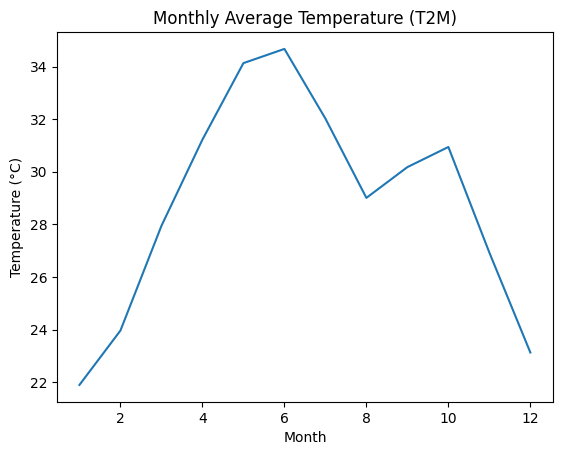

In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

Temperature Trend Analysis

- The highest average temperature occurs around June.
- The lowest average temperature occurs around the month of January.
- The pattern shows a clear seasonal trend, with temperatures increasing and decreasing throughout the year.
-This indicates clear climatic seasonality in Kenya, with warmer and cooler periods

In [47]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain

Month
1        0.32
2        0.13
3        0.07
4        3.57
5      115.23
6      101.03
7      774.21
8     1152.10
9      378.93
10     109.86
11       3.18
12       6.41
Name: PRECTOTCORR, dtype: float64

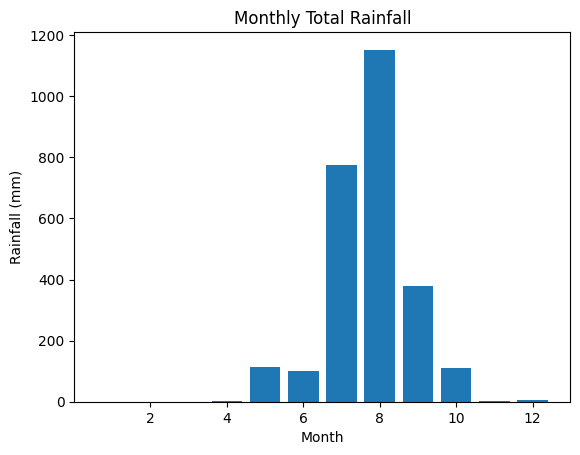

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

Rainfall Analysis 

- Monthly rainfall shows strong variability, with most months receiving very low or zero precipitation.
- A few months exhibit sharp peaks in rainfall, indicating short-lived but intense rainy periods.
- The distribution confirms that rainfall in Sudan is highly irregular and event-driven rather than continuous.
- Overall, the region is predominantly dry, with rainfall concentrated in limited seasonal windows.
- This pattern is consistent with an arid to semi-arid climate characterized by long dry spells and occasional heavy rainfall events.

### 5. Correlation and Relationship Analysis

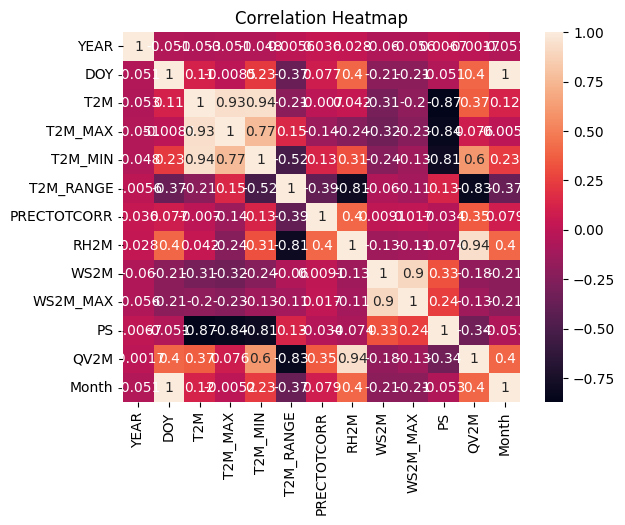

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Correlation Analysis

- Strong positive correlations are observed between temperature variables (T2M, T2M_MAX, T2M_MIN), indicating consistent temperature behavior across the dataset.
- Wind speed variables show moderate relationships, suggesting variable but structured wind patterns in the region.
- Temperature and humidity show a weak negative relationship, which is expected in hot and arid climates where higher temperatures are associated with lower moisture levels.
- Precipitation shows weak and inconsistent correlations with most variables due to its highly irregular and event-driven nature.
- Overall, the correlations reflect realistic atmospheric dynamics in a hot, dry, and highly variable climate system.

In [50]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### 6. Distribution Analysis

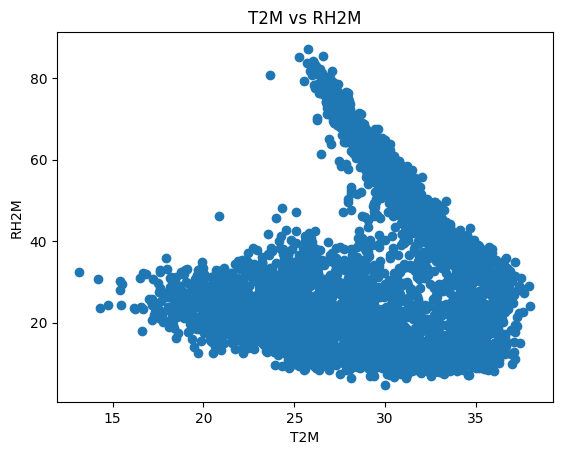

In [51]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("T2M vs RH2M")
plt.show()

Temperature vs Humidity 

- A weak negative relationship exists between temperature and humidity.
- Higher temperatures are generally associated with lower humidity levels, especially during hot dry periods.
- The very low humidity values in the dataset strengthen this inverse relationship.
- This pattern is typical of hot and arid climates where increased heat reduces atmospheric moisture content.

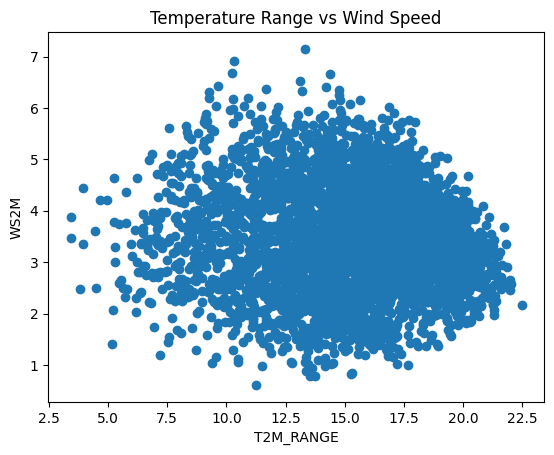

In [52]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temperature Range vs Wind Speed")
plt.show()

Temperature Range vs Wind Speed

- There is no strong linear relationship between temperature range (T2M_RANGE) and wind speed (WS2M).
- Wind speed variations appear largely independent of daily temperature fluctuations.
- Occasional increases in wind speed are more likely linked to regional weather events rather than temperature variability.
- Overall, the relationship is weak and does not show a consistent pattern.

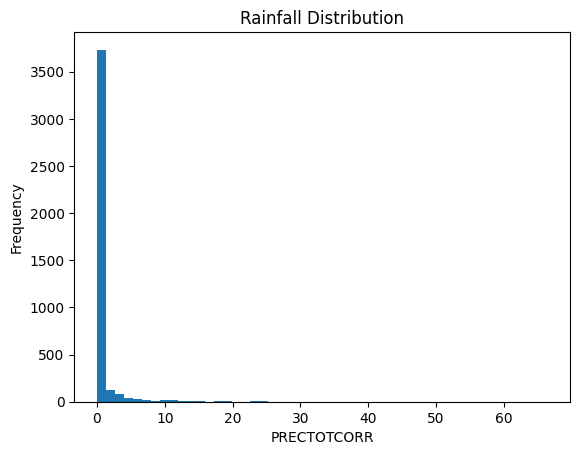

In [53]:
plt.figure()
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

Rainfall Distribution (Sudan)

- Rainfall is highly skewed, with a large number of days recording zero precipitation.
- Most rainfall values are close to zero, indicating long dry periods dominate the dataset.
- Occasional extreme rainfall events create sharp spikes in the distribution.
- This reflects a typical arid to semi-arid climate with rare but intense rainfall occurrences.

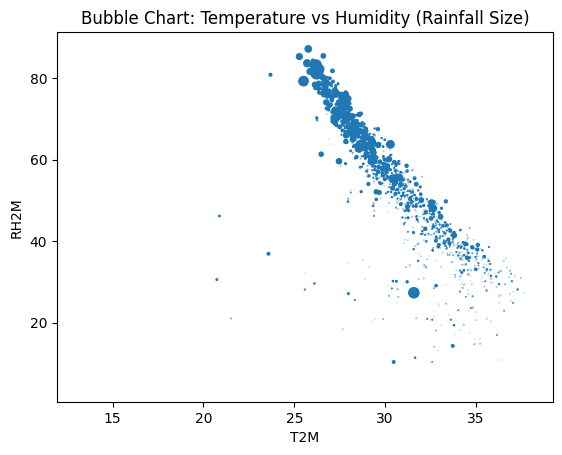

In [54]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Bubble Chart: Temperature vs Humidity (Rainfall Size)")
plt.show()

Bubble Chart Analysis 

- The bubble chart shows a weak relationship between temperature and rainfall, with most points concentrated at low precipitation values.
- Larger rainfall events appear as isolated bubbles, indicating rare but intense precipitation occurrences.
- Higher temperatures generally correspond to low rainfall values, reinforcing the dry climate pattern.
- Wind speed does not show a strong clustering pattern with temperature or rainfall, suggesting independent variability.
- Overall, the visualization highlights Sudan’s hot and dry climate with sporadic extreme weather events.